<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
<class 'pandas.core.frame.DataF

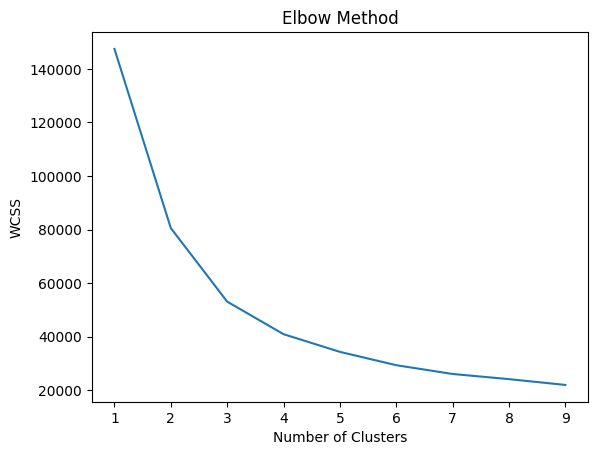

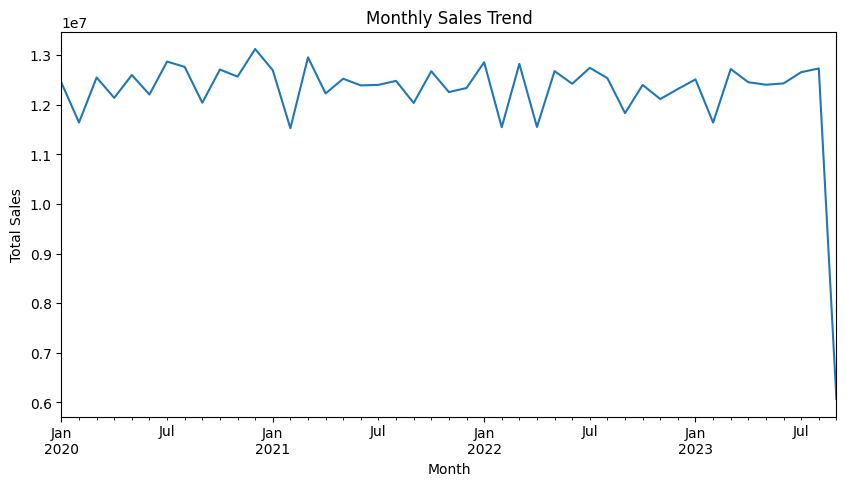

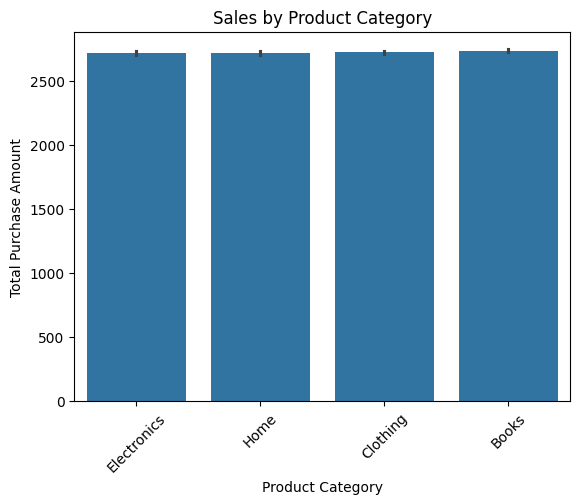

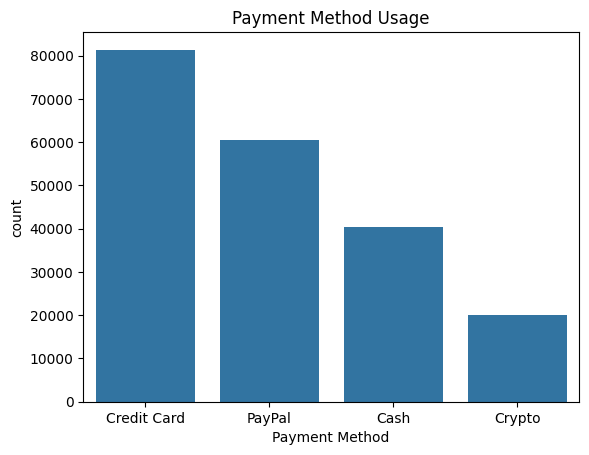

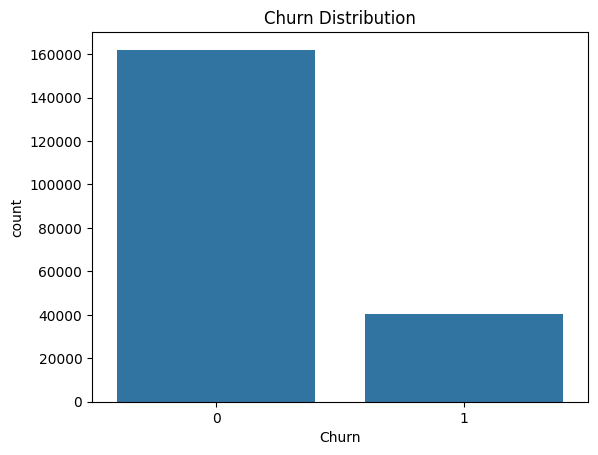

In [22]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for clustering and preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings("ignore")


# Load the dataset
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

# Display first few rows
df.head()

#Understanding the Dataset
df.info()
df.describe()
df.isnull().sum()

# Remove duplicate records

df.drop_duplicates(inplace=True)

df = df.dropna()

df.columns = df.columns.str.strip()
df.columns

# Drop unnecessary column

df = df.drop(columns=['Customer Age'])
df.info()

# Convert Purchase Date column to datetime format

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')
df = df.dropna(subset=['Purchase Date'])

df.info()

# Set reference date as latest purchase date
reference_date = df['Purchase Date'].max()

# Calculate RFM metrics
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (reference_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

from sklearn.preprocessing import StandardScaler

# Scale the RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Test cluster numbers from 1 to 9
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Apply K-Means clustering

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

# Analyze average RFM values per cluster

rfm.groupby('Cluster').mean()


# Map cluster numbers to segment names
rfm['Segment'] = rfm['Cluster'].map({
    0: 'Loyal Customers',
    1: 'At Risk',
    2: 'Regular Customers',
    3: 'New Customers'
})

df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

# Plot monthly sales trend

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

import seaborn as sns

sns.barplot(x='Product Category',
            y='Total Purchase Amount',
            data=df)
plt.xticks(rotation=45)
plt.title("Sales by Product Category")
plt.show()

sns.countplot(x='Payment Method', data=df)
plt.title("Payment Method Usage")
plt.show()

df['Churn'].value_counts()
# Calculate churn percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate

df.groupby('Churn')['Total Purchase Amount'].mean()

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()





**Customer Behavior Analysis for Alfido Tech**

In this project, customer transaction data is analyzed to understand purchasing behavior and identify different types of customers. Businesses can use this type of analysis to improve customer engagement and reduce churn. The dataset is first cleaned and prepared. After that, RFM (Recency, Frequency, Monetary) analysis is performed to understand how recently customers purchased, how often they purchase, and how much they spend. Then K-Means clustering is used to group customers into segments. Finally, visualizations are created to study sales patterns and churn behavior.

**Importing Required Libraries**

In this step, the required Python libraries are imported. Pandas and NumPy are used for data handling and numerical operations. Matplotlib and Seaborn are used to create graphs and visualizations. Scikit-learn is used for machine learning tasks such as scaling data and applying clustering algorithms.

**Loading the Dataset**

Here the dataset is loaded into the notebook using pandas. The dataset contains information about customer purchases such as purchase date, total purchase amount, product category, payment method, and churn status. Displaying the first few rows helps us understand how the data looks.

**Understanding the Dataset**

Before starting analysis, it is important to explore the dataset. The dataset information shows the number of rows, columns, and data types. Summary statistics provide information such as mean, minimum, and maximum values. Checking missing values helps identify whether any cleaning is required.

**Data Cleaning**

Data cleaning is an important step before performing analysis. Duplicate rows are removed to avoid repeated data. Rows containing missing values are removed to maintain accuracy. Column names are cleaned by removing extra spaces. The column "Customer Age" is removed because it is not required for this analysis.

**Converting Purchase Date**

The purchase date column is converted into datetime format so that time-based analysis can be performed. This allows us to calculate recency values and analyze purchase trends over time. Any rows with invalid date values are removed.

**Creating RFM Features**

RFM analysis is used to understand customer purchasing behavior. RFM stands for Recency, Frequency, and Monetary value.

Recency represents how recently a customer made a purchase. Frequency represents how many times the customer purchased. Monetary represents the total amount spent by the customer.

These three values help identify valuable customers and understand purchasing patterns.

**Scaling the Data**

Before applying machine learning algorithms, the RFM values are scaled using StandardScaler. Scaling ensures that all variables are on a similar range. This prevents variables with large values from dominating the clustering process.

**Finding the Optimal Number of Clusters**

The Elbow Method is used to determine the best number of clusters for the K-Means algorithm. The method calculates the WCSS (Within Cluster Sum of Squares) for different cluster values. The point where the graph starts bending like an elbow indicates the optimal number of clusters.

**Applying K-Means Clustering**

After identifying the number of clusters, the K-Means clustering algorithm is applied to segment the customers. Each customer is assigned to a cluster based on their RFM values. Customers in the same cluster have similar purchasing behavior.

**Analyzing Customer Segments**

The average Recency, Frequency, and Monetary values are calculated for each cluster. This helps understand the characteristics of customers in each group. Based on these values, clusters can be interpreted as Loyal Customers, Regular Customers, New Customers, or At Risk customers.

**Monthly Sales Trend Analysis**

Monthly sales trends are analyzed to observe how revenue changes over time. This helps identify peak sales periods and seasonal patterns. Businesses can use this information to plan marketing campaigns and inventory management.

**Product Category Analysis**

This visualization shows how sales are distributed across different product categories. It helps identify which categories generate the highest revenue and which categories may need improvement in marketing.

**Payment Method Analysis**

The payment method chart shows which payment options are most commonly used by customers. Understanding customer payment preferences helps improve the checkout experience and payment processing.

**Churn Analysis**

Churn analysis helps identify customers who stopped purchasing from the platform. By comparing churned and active customers, businesses can understand potential reasons for customer loss and develop strategies to retain them.

**Insights from the Analysis**

From the analysis, it can be observed that customers have different purchasing behaviors. Some customers purchase frequently and spend more money, while others purchase only occasionally. Sales trends show variation across months, indicating possible seasonal demand. Product category analysis highlights the most popular products. Churn analysis also indicates that some customers may stop purchasing if they are not properly engaged.

**Recommendations for Alfido Tech**

Based on the analysis, several recommendations can be suggested. Alfido Tech can use customer segmentation to create targeted marketing campaigns for different types of customers. Loyal customers can be rewarded with loyalty programs to maintain engagement. At-risk customers can be re-engaged through promotional offers or reminders. Product recommendation systems can help increase sales by suggesting related products. Seasonal promotions can also be used to take advantage of peak sales periods.